# 🧠 Brain Tumor Segmentation Support System — SIC Capstone v3 (BraTS 2023)
### Pipeline Hoàn Chỉnh: EDA → Tiền Xử Lý Z-Score NPZ → Huấn Luyện 3D U-Net & Swin UNETR → Hậu Xử Lý → Đánh Giá → Trực Quan Hóa → Báo Cáo PDF

| Feature | Description |
|---|---|
| **Mục tiêu** | Phân đoạn tự động u não 3D (BraTS 2023) thành 3 vùng: WT, TC, ET |
| **Kiến trúc** | 3D U-Net Baseline & Swin UNETR (Transformer) |
| **Pipeline** | Tải Data Drive/Local, EDA chi tiết, Tiền xử lý Z-score NPZ, Huấn luyện (CosineAnnealingLR + Early Stopping), Hậu xử lý CCA, Đánh giá (Dice/IoU/Volume), Translucent Overlay Visualizer, Xuất PDF & ONNX/TorchScript |
| **Phiên bản** | v3 (Tối ưu hóa Production & Chuẩn PRD Capstone 2026) |

## 1. Cài Đặt Môi Trường, Tải Dữ Liệu & Mount Google Drive
Cài đặt các thư viện phụ thuộc (`monai`, `nibabel`, `gdown`, `fpdf2`, `torchinfo`, `onnx`, `onnxscript`, v.v.) và tự động tải dữ liệu từ Google Drive nếu chưa có sẵn trên máy.

In [1]:
!pip install -q monai nibabel fpdf2 matplotlib torchinfo tqdm scikit-learn pandas scipy gdown onnx onnxscript

import os
import glob
import time
import json
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import nibabel as nib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.dataloader import default_collate
from tqdm.auto import tqdm
from scipy.ndimage import binary_dilation, label as scipy_label
from sklearn.model_selection import train_test_split

import monai
from monai.transforms import (
    Compose, EnsureTyped, RandCropByPosNegLabeld, RandFlipd,
    RandRotate90d, RandScaleIntensityd, RandShiftIntensityd, RandGaussianNoised
)
from monai.networks.nets import UNet, SwinUNETR
from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference
from torchinfo import summary
from fpdf import FPDF
from datetime import datetime

# 1. Mount Google Drive nếu chạy trên Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IS_COLAB = True
    print("✅ Mounted Google Drive thành công!")
except Exception:
    IS_COLAB = False
    print("ℹ️ Đang chạy trên môi trường Cục bộ (Local).")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.0/337.0 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 19.2 MB/s eta 0:00:00
Mounted at /content/drive
✅ Mounted Google Drive thành công!


## 2. Cấu Hình Tập Trung (CFG) & Tự Động Quét/Tải Dữ Liệu
Quản lý siêu tham số qua class `CFG`, tự động quét các đường dẫn dữ liệu cục bộ hoặc tải từ Google Drive Folder ID `1lcsNNbbf20jDEgHMDQ2fGdyQjNtg-2M6`.

In [2]:
class CFG:
    seed = 42
    modalities = ['t1n', 't1c', 't2w', 't2f']
    in_channels = 4
    out_channels = 4  # 0: Background, 1: NCR/NET, 2: ED, 3: ET
    classes = ['Background', 'NCR/NET', 'ED', 'ET']
    target_shape = (240, 240, 155)
    patch_size = (96, 96, 96)

    val_split = 0.2
    val_subset_size = 2   # Dataset test 6 cases -> val 1-2 cases
    batch_size = 2
    num_samples = 2
    num_workers = 0       # Windows: đặt 0 để tránh lỗi multiprocessing

    learning_rate = 2e-4
    weight_decay = 1e-4
    max_epochs = 20
    val_interval = 2
    early_stopping_patience = 5  # Dừng sớm nếu không cải thiện sau 5 lần val

    sw_batch_size = 2
    sw_overlap = 0.5
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    monai.utils.misc.set_determinism(seed=seed)

set_seed(CFG.seed)
print(f"🖥️ Thiết bị sử dụng: {CFG.device}")
if torch.cuda.is_available():
    print(f"⚡ GPU: {torch.cuda.get_device_name(0)}")

# ===== Quét đường dẫn dữ liệu =====
RAW_DATA_CANDIDATES = [
    r'T:\AI SAMSUNG\Dataset\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData',
    r'T:/AI SAMSUNG/Dataset/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData',
    r't:\AI SAMSUNG\DoAn\Brain-Tumor-Segmentation-Support-System-main\Datasets\synthetic_brats',
    r't:/AI SAMSUNG/DoAn/Brain-Tumor-Segmentation-Support-System-main/Datasets/synthetic_brats',
    'Datasets/synthetic_brats',
    '../DoAn/Brain-Tumor-Segmentation-Support-System-main/Datasets/synthetic_brats',
    './data/raw/synthetic_brats',
    './data/synthetic_brats',
    '/content/drive/MyDrive/synthetic_brats',
    '/content/drive/MyDrive/BraTS2023_Raw',
    './data/raw'
]

DATA_ROOT = next((p for p in RAW_DATA_CANDIDATES if os.path.exists(p) and len(glob.glob(os.path.join(p, '*'))) > 0), None)

# Nếu chưa có data cục bộ, tự động tải từ Google Drive qua gdown
DRIVE_FOLDER_ID = "1lcsNNbbf20jDEgHMDQ2fGdyQjNtg-2M6"
if DATA_ROOT is None:
    print(f"🌐 Không tìm thấy dữ liệu cục bộ. Đang tải tự động từ Google Drive ({DRIVE_FOLDER_ID})...")
    download_target = "./data/raw/synthetic_brats"
    os.makedirs(download_target, exist_ok=True)
    try:
        import gdown
        gdown.download_folder(id=DRIVE_FOLDER_ID, output=download_target, quiet=False, use_cookies=False)
        if os.path.exists(download_target) and len(glob.glob(os.path.join(download_target, '*'))) > 0:
            DATA_ROOT = download_target
            print(f"✅ Tải dữ liệu từ Google Drive thành công về: {DATA_ROOT}")
    except Exception as e:
        print(f"⚠️ Không thể tải tự động từ Drive: {e}")

# Đặt PREPROCESSED_DIR thông minh cùng cấp với DATA_ROOT hoặc thư mục project
if DATA_ROOT is not None:
    PREPROCESSED_DIR = os.path.join(os.path.dirname(os.path.abspath(DATA_ROOT)), 'processed_npz')
else:
    PREPROCESSED_DIR = './data/processed_npz'

# QUAN TRỌNG: checkpoint/model phải nằm trên Google Drive khi chạy Colab,
# nếu không sẽ mất sạch khi runtime bị ngắt kết nối (disconnect/timeout).
if IS_COLAB and os.path.exists('/content/drive/MyDrive'):
    PROJECT_ROOT = '/content/drive/MyDrive/BraTS_Project'
else:
    PROJECT_ROOT = '.'

CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints')
MODEL_DIR = os.path.join(PROJECT_ROOT, 'models')
LOG_DIR = os.path.join(PROJECT_ROOT, 'logs')

os.makedirs(PREPROCESSED_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print(f"📁 Đường dẫn được cấu hình:")
print(f"  - DATA_ROOT (Raw): {DATA_ROOT}")
print(f"  - PREPROCESSED_DIR: {PREPROCESSED_DIR}")
print(f"  - CHECKPOINT_DIR: {CHECKPOINT_DIR}  (persist={'Google Drive' if IS_COLAB else 'local'})")
print(f"  - MODEL_DIR: {MODEL_DIR}")
print(f"  - LOG_DIR: {LOG_DIR}")

🖥️ Thiết bị sử dụng: cuda
⚡ GPU: Tesla T4
📁 Đường dẫn được cấu hình:
  - DATA_ROOT (Raw): /content/drive/MyDrive/synthetic_brats
  - PREPROCESSED_DIR: /content/drive/MyDrive/processed_npz
  - CHECKPOINT_DIR: /content/drive/MyDrive/BraTS_Project/checkpoints  (persist=Google Drive)
  - MODEL_DIR: /content/drive/MyDrive/BraTS_Project/models
  - LOG_DIR: /content/drive/MyDrive/BraTS_Project/logs


## 3. Pipeline Tiền Xử Lý NPZ Cache & Chuẩn Hóa Cường Độ (Z-Score)
Đọc dữ liệu NIfTI, cắt ngưỡng Percentile 0.5% - 99.5%, chuẩn hóa Z-score trên vùng mô não (Brain Mask), remap nhãn chuẩn BraTS và nén lưu dưới dạng `.npz` để tăng tốc độ I/O.

In [3]:
# BraTS 2023 Labels gốc: 0=BG, 1=NCR/NET, 2=ED, 4=ET (KHÔNG có label 3)
# Remap chuẩn: ET(4) → 3 để out_channels=4 (0,1,2,3)
LABEL_REMAP = {0: 0, 1: 1, 2: 2, 4: 3}

def load_and_normalize_case_nifti(case_path):
    vols = []
    for mod in CFG.modalities:
        fpath = glob.glob(os.path.join(case_path, f"*{mod}*.nii.gz"))
        if not fpath:
            return None
        arr = nib.load(fpath[0]).get_fdata(dtype=np.float32)

        # Z-score Normalization theo từng vùng não (Brain Mask)
        brain_mask = arr > 0
        if brain_mask.any():
            vals = arr[brain_mask]
            p_low, p_high = np.percentile(vals, [0.5, 99.5])
            arr = np.clip(arr, p_low, p_high)
            mean_val, std_val = arr[brain_mask].mean(), arr[brain_mask].std()
            if std_val > 1e-6:
                arr = (arr - mean_val) / std_val
            arr[~brain_mask] = 0.0
        vols.append(arr)

    seg_path = glob.glob(os.path.join(case_path, f"*seg*.nii.gz"))
    if not seg_path:
        return None

    # Đọc mask phân đoạn (load float32 sau đó cast int16 để tương thích mọi phiên bản nibabel)
    raw_seg = nib.load(seg_path[0]).get_fdata(dtype=np.float32).astype(np.int16)

    seg = np.zeros_like(raw_seg, dtype=np.int16)
    for k, v in LABEL_REMAP.items():
        seg[raw_seg == k] = v

    img = np.stack(vols, axis=0).astype(np.float32)  # (4, H, W, D)
    return img, seg

def preprocess_single_case(case_dir, out_path):
    res = load_and_normalize_case_nifti(case_dir)
    if res is None:
        return False
    img, seg = res
    np.savez_compressed(out_path, image=img, label=seg)
    return True

def ensure_preprocessed_npz():
    if os.path.exists(PREPROCESSED_DIR):
        npz_files = glob.glob(os.path.join(PREPROCESSED_DIR, "*.npz"))
        if len(npz_files) > 0:
            print(f"✅ Tìm thấy {len(npz_files)} file NPZ đã chuẩn hóa Z-score. Sử dụng NPZ Cache.")
            return sorted([os.path.basename(f).replace('.npz', '') for f in npz_files])

    if DATA_ROOT is None or not os.path.exists(DATA_ROOT):
        print("❌ Không tìm thấy dữ liệu Raw hoặc NPZ!")
        return []

    case_dirs = sorted([d for d in glob.glob(os.path.join(DATA_ROOT, "*")) if os.path.isdir(d)])
    print(f"⏳ Tìm thấy {len(case_dirs)} cases raw tại: {DATA_ROOT}")
    print(f"   Tiến hành Z-score normalization và lưu NPZ vào: {PREPROCESSED_DIR}")

    all_cases = []
    for c_dir in tqdm(case_dirs, desc="Preprocess NPZ"):
        cid = os.path.basename(c_dir)
        out_p = os.path.join(PREPROCESSED_DIR, f"{cid}.npz")
        if not os.path.exists(out_p):
            ok = preprocess_single_case(c_dir, out_p)
            if not ok:
                print(f"   ⚠️ Bỏ qua {cid}: không tìm thấy đủ file các chuỗi xung MRI")
                continue
        all_cases.append(cid)

    return all_cases

all_case_ids = ensure_preprocessed_npz()

# Serialize case list để tránh mất khi restart kernel
_cache_ids_path = os.path.join(CHECKPOINT_DIR, 'case_ids.json')
if len(all_case_ids) > 0:
    with open(_cache_ids_path, 'w') as _f:
        json.dump(all_case_ids, _f)
elif os.path.exists(_cache_ids_path):
    with open(_cache_ids_path) as _f:
        all_case_ids = json.load(_f)
    print(f"✅ Đọc từ cache: {len(all_case_ids)} cases")

print(f"✅ Tổng số cases sẵn sàng: {len(all_case_ids)}")
if len(all_case_ids) > 0:
    print(f"   Danh sách cases: {all_case_ids}")

✅ Tìm thấy 1016 file NPZ đã chuẩn hóa Z-score. Sử dụng NPZ Cache.
✅ Tổng số cases sẵn sàng: 1016
   Danh sách cases: ['BraTS-GLI-00000-000', 'BraTS-GLI-00002-000', 'BraTS-GLI-00003-000', 'BraTS-GLI-00005-000', 'BraTS-GLI-00006-000', 'BraTS-GLI-00008-000', 'BraTS-GLI-00008-001', 'BraTS-GLI-00009-000', 'BraTS-GLI-00009-001', 'BraTS-GLI-00011-000', 'BraTS-GLI-00012-000', 'BraTS-GLI-00014-000', 'BraTS-GLI-00014-001', 'BraTS-GLI-00016-000', 'BraTS-GLI-00016-001', 'BraTS-GLI-00017-000', 'BraTS-GLI-00017-001', 'BraTS-GLI-00018-000', 'BraTS-GLI-00019-000', 'BraTS-GLI-00020-000', 'BraTS-GLI-00020-001', 'BraTS-GLI-00021-000', 'BraTS-GLI-00021-001', 'BraTS-GLI-00022-000', 'BraTS-GLI-00022-001', 'BraTS-GLI-00024-000', 'BraTS-GLI-00024-001', 'BraTS-GLI-00025-000', 'BraTS-GLI-00026-000', 'BraTS-GLI-00028-000', 'BraTS-GLI-00030-000', 'BraTS-GLI-00031-000', 'BraTS-GLI-00031-001', 'BraTS-GLI-00032-000', 'BraTS-GLI-00032-001', 'BraTS-GLI-00033-000', 'BraTS-GLI-00035-000', 'BraTS-GLI-00036-000', 'BraTS-G

In [4]:
# ============================================================
# Đồng bộ NPZ cache từ Google Drive về ổ đĩa cục bộ (Local Disk)
# LÝ DO: đọc trực tiếp .npz từ Drive (mount qua FUSE/mạng) hàng trăm lần trong
# suốt quá trình train rất dễ bị ConnectionAbortedError -> BadZipFile khi Drive
# mount bị chập chờn (đúng lỗi vừa gặp). Ổ đĩa cục bộ /content ổn định và nhanh hơn.
# Chỉ đồng bộ 1 LẦN mỗi phiên (session) — không lặp lại mỗi epoch.
# ============================================================
import shutil

DRIVE_PREPROCESSED_DIR = PREPROCESSED_DIR  # giữ lại đường dẫn gốc trên Drive để tham chiếu

if IS_COLAB and DRIVE_PREPROCESSED_DIR.startswith('/content/drive') and len(all_case_ids) > 0:
    LOCAL_NPZ_DIR = '/content/local_npz_cache'
    os.makedirs(LOCAL_NPZ_DIR, exist_ok=True)

    def _sync_one_npz(cid, retries=3):
        src = os.path.join(DRIVE_PREPROCESSED_DIR, f"{cid}.npz")
        dst = os.path.join(LOCAL_NPZ_DIR, f"{cid}.npz")
        if os.path.exists(dst) and os.path.exists(src) and os.path.getsize(dst) == os.path.getsize(src):
            return True
        for attempt in range(retries):
            try:
                tmp_dst = dst + '.tmp'
                shutil.copyfile(src, tmp_dst)
                os.replace(tmp_dst, dst)  # copy atomic — tránh file dở dang nếu bị ngắt giữa chừng
                return True
            except Exception as e:
                print(f"   ⚠️ Lỗi đồng bộ {cid} (lần {attempt+1}/{retries}): {e}")
                time.sleep(2.0)
        return False

    print(f"⏳ Đang đồng bộ {len(all_case_ids)} file NPZ từ Drive → local ({LOCAL_NPZ_DIR})...")
    failed_cases = []
    for cid in tqdm(all_case_ids, desc="Sync NPZ → Local"):
        if not _sync_one_npz(cid):
            failed_cases.append(cid)

    if failed_cases:
        print(f"⚠️ {len(failed_cases)} case đồng bộ thất bại, loại khỏi tập train/val: {failed_cases}")
        all_case_ids = [c for c in all_case_ids if c not in failed_cases]

    # Từ đây, TOÀN BỘ pipeline phía sau (EDA, Dataset, DataLoader) tự động đọc từ local
    # vì chúng đều tham chiếu qua biến global PREPROCESSED_DIR.
    PREPROCESSED_DIR = LOCAL_NPZ_DIR
    print(f"✅ Đồng bộ xong {len(all_case_ids)} case. PREPROCESSED_DIR (dùng để train) = {PREPROCESSED_DIR}")
else:
    LOCAL_NPZ_DIR = PREPROCESSED_DIR
    print(f"ℹ️ Không cần đồng bộ (đã ở local hoặc không chạy Colab). PREPROCESSED_DIR = {PREPROCESSED_DIR}")


⏳ Đang đồng bộ 1016 file NPZ từ Drive → local (/content/local_npz_cache)...


Sync NPZ → Local:   0%|          | 0/1016 [00:00<?, ?it/s]

   ⚠️ Lỗi đồng bộ BraTS-GLI-00012-000 (lần 1/3): [Errno 107] Transport endpoint is not connected
   ⚠️ Lỗi đồng bộ BraTS-GLI-00012-000 (lần 2/3): [Errno 2] No such file or directory: '/content/drive/MyDrive/processed_npz/BraTS-GLI-00012-000.npz'
✅ Đồng bộ xong 1016 case. PREPROCESSED_DIR (dùng để train) = /content/local_npz_cache


## 4. Khám Phá Dữ Liệu (EDA) — Data Understanding
### 4.1. Structure inspection & label inventory

In [5]:
def eda_structure(case_id):
    print(f"🔍 Kiểm tra cấu trúc case: {case_id}")
    npz_path = os.path.join(PREPROCESSED_DIR, f"{case_id}.npz")
    if os.path.exists(npz_path):
        data = np.load(npz_path)
        img, seg = data['image'], data['label']
        print(f"  - Shape Image: {img.shape}, Type: {img.dtype}, Min: {img.min():.2f}, Max: {img.max():.2f}")
        print(f"  - Shape Label: {seg.shape}, Type: {seg.dtype}, Unique Labels: {np.unique(seg)}")

        unique, counts = np.unique(seg, return_counts=True)
        total = seg.size
        print("  - Label Inventory:")
        for u, c in zip(unique, counts):
            lbl_name = CFG.classes[u] if u < len(CFG.classes) else f"Label {u}"
            print(f"      {lbl_name} (Label {u}): {c:,} voxels ({c/total*100:.2f}%)")
    else:
        print("  - File NPZ không tồn tại!")

if len(all_case_ids) > 0:
    eda_structure(all_case_ids[0])

🔍 Kiểm tra cấu trúc case: BraTS-GLI-00000-000
  - Shape Image: (4, 240, 240, 155), Type: float32, Min: -3.36, Max: 6.10
  - Shape Label: (240, 240, 155), Type: int16, Unique Labels: [0 1 2]
  - Label Inventory:
      Background (Label 0): 8,903,426 voxels (99.72%)
      NCR/NET (Label 1): 11,738 voxels (0.13%)
      ED (Label 2): 12,836 voxels (0.14%)


### 4.2. Intensity distributions & class statistics

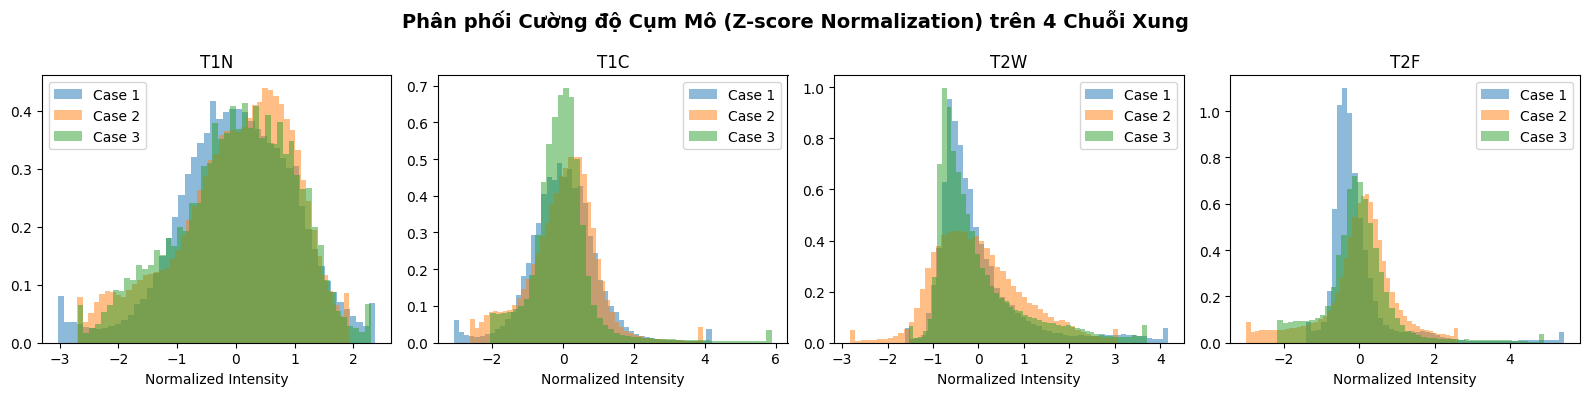

In [6]:
def eda_intensity_dist(case_ids, num_samples=3):
    if len(case_ids) == 0:
        return
    samples = np.random.choice(case_ids, min(num_samples, len(case_ids)), replace=False)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    for i, cid in enumerate(samples):
        npz_path = os.path.join(PREPROCESSED_DIR, f"{cid}.npz")
        data = np.load(npz_path)
        img = data['image']  # (4, H, W, D)

        for c in range(4):
            vols = img[c].flatten()
            vols = vols[vols != 0]  # bỏ background 0
            axes[c].hist(vols, bins=50, alpha=0.5, label=f"Case {i+1}", density=True)
            axes[c].set_title(CFG.modalities[c].upper())
            axes[c].set_xlabel("Normalized Intensity")
            axes[c].legend()

    plt.suptitle("Phân phối Cường độ Cụm Mô (Z-score Normalization) trên 4 Chuỗi Xung", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

if len(all_case_ids) > 0:
    eda_intensity_dist(all_case_ids)

### 4.3. Visualizing 4 modalities & GT mask overlay on axial slice

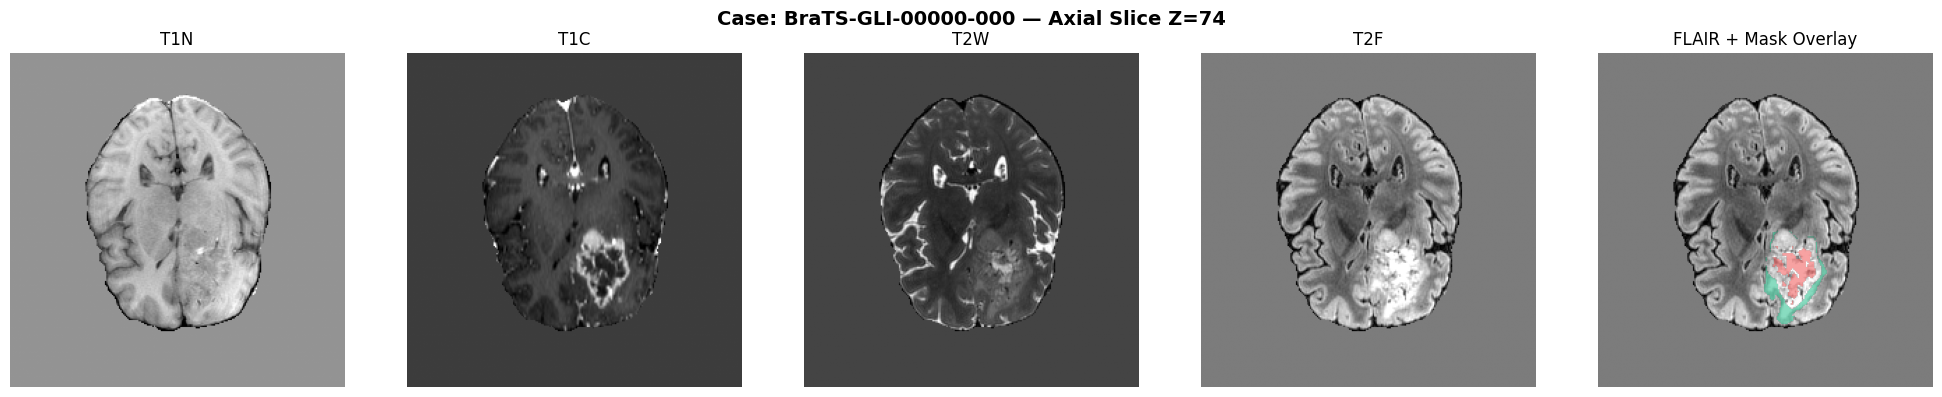

In [7]:
def visualize_slice(case_id):
    npz_path = os.path.join(PREPROCESSED_DIR, f"{case_id}.npz")
    if not os.path.exists(npz_path):
        return
    data = np.load(npz_path)
    img, seg = data['image'], data['label']

    # Tìm lát cắt axial có diện tích khối u lớn nhất
    slice_counts = np.sum(seg > 0, axis=(0, 1))
    z = np.argmax(slice_counts) if slice_counts.max() > 0 else seg.shape[2] // 2

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for c in range(4):
        axes[c].imshow(img[c, :, :, z].T, cmap='gray', origin='lower')
        axes[c].set_title(CFG.modalities[c].upper())
        axes[c].axis('off')

    cmap_seg = ListedColormap(['none', '#EF4444', '#10B981', '#F59E0B'])
    axes[4].imshow(img[3, :, :, z].T, cmap='gray', origin='lower')
    axes[4].imshow(seg[:, :, z].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower')
    axes[4].set_title('FLAIR + Mask Overlay')
    axes[4].axis('off')

    plt.suptitle(f"Case: {case_id} — Axial Slice Z={z}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

if len(all_case_ids) > 0:
    visualize_slice(all_case_ids[0])

## 5. Phân Chia Dataset & Khởi Tạo DataLoaders
Phân chia Train/Validation set và khởi tạo PyTorch Dataset & MONAI Augmentation DataLoaders.

In [8]:
class PreprocessedBraTSDataset3D(Dataset):
    def __init__(self, case_ids, transform=None):
        self.case_ids = case_ids
        self.transform = transform

    def __len__(self):
        return len(self.case_ids)

    def __getitem__(self, idx):
        npz_path = os.path.join(PREPROCESSED_DIR, f"{self.case_ids[idx]}.npz")
        # Retry nhẹ: phòng trường hợp file local bị lỗi (vd. copy dở dang từ phiên trước
        # khi chưa có bước đồng bộ atomic), tự đọc lại vài lần trước khi báo lỗi.
        last_err = None
        data = None
        for _attempt in range(3):
            try:
                data = np.load(npz_path)
                img = data['image'].astype(np.float32)
                lbl = data['label'].astype(np.int64)
                last_err = None
                break
            except Exception as e:
                last_err = e
                time.sleep(0.5)
        if last_err is not None:
            raise RuntimeError(f"Không đọc được {npz_path} sau 3 lần thử: {last_err}")
        if lbl.ndim == 3:
            lbl = np.expand_dims(lbl, 0)

        item = {'image': img, 'label': lbl, 'case_id': self.case_ids[idx]}
        if self.transform:
            item = self.transform(item)
        return item

if len(all_case_ids) > 0:
    # Với dataset nhỏ (6 cases): đảm bảo có ít nhất 1 case mỗi split
    _val_split = CFG.val_split if len(all_case_ids) >= 5 else 1/len(all_case_ids)
    train_cases, val_cases = train_test_split(all_case_ids, test_size=_val_split, random_state=CFG.seed)
    val_cases_fast = val_cases[:max(1, CFG.val_subset_size)]

    train_transforms = Compose([
        RandCropByPosNegLabeld(
            keys=["image", "label"],
            label_key="label",
            spatial_size=CFG.patch_size,
            pos=1,
            neg=1,
            num_samples=CFG.num_samples,
            allow_smaller=True
        ),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
        RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
        RandScaleIntensityd(keys="image", factors=0.1, prob=0.5),
        RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),
        RandGaussianNoised(keys="image", prob=0.3, mean=0.0, std=0.05),
        EnsureTyped(keys=["image", "label"], device=torch.device('cpu'), track_meta=False)
    ])

    val_transforms = Compose([
        EnsureTyped(keys=["image", "label"], device=torch.device('cpu'), track_meta=False)
    ])

    train_ds = PreprocessedBraTSDataset3D(train_cases, transform=train_transforms)
    val_ds_fast = PreprocessedBraTSDataset3D(val_cases_fast, transform=val_transforms)
    val_ds_full = PreprocessedBraTSDataset3D(val_cases, transform=val_transforms)

    def collate_fn_list(batch):
        """Flatten list-of-patches từ RandCropByPosNegLabeld rồi collate tensor."""
        flat_batch = []
        for item in batch:
            if isinstance(item, list):
                flat_batch.extend(item)
            else:
                flat_batch.append(item)
        # Loại bỏ case_id (string) trước khi collate tensor
        tensor_batch = [{k: v for k, v in b.items() if k != 'case_id'} for b in flat_batch]
        return default_collate(tensor_batch)

    train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                              num_workers=CFG.num_workers, collate_fn=collate_fn_list)
    val_loader_fast = DataLoader(val_ds_fast, batch_size=1, num_workers=0)
    val_loader_full = DataLoader(val_ds_full, batch_size=1, num_workers=0)

    print(f"✅ Khởi tạo DataLoader thành công!")
    print(f"  - Train cases ({len(train_cases)}): {train_cases}")
    print(f"  - Val cases Fast ({len(val_cases_fast)}): {val_cases_fast}")
    print(f"  - Val cases Full ({len(val_cases)}): {val_cases}")

✅ Khởi tạo DataLoader thành công!
  - Train cases (812): ['BraTS-GLI-00612-001', 'BraTS-GLI-01214-000', 'BraTS-GLI-00407-000', 'BraTS-GLI-00740-000', 'BraTS-GLI-00772-000', 'BraTS-GLI-01160-000', 'BraTS-GLI-00652-000', 'BraTS-GLI-00087-001', 'BraTS-GLI-00028-000', 'BraTS-GLI-01477-000', 'BraTS-GLI-01485-000', 'BraTS-GLI-00443-000', 'BraTS-GLI-01153-000', 'BraTS-GLI-00663-000', 'BraTS-GLI-00290-000', 'BraTS-GLI-01077-000', 'BraTS-GLI-00341-000', 'BraTS-GLI-00806-000', 'BraTS-GLI-00068-000', 'BraTS-GLI-00227-000', 'BraTS-GLI-00478-001', 'BraTS-GLI-01487-000', 'BraTS-GLI-01432-000', 'BraTS-GLI-01026-000', 'BraTS-GLI-01176-000', 'BraTS-GLI-00479-000', 'BraTS-GLI-00805-000', 'BraTS-GLI-00597-000', 'BraTS-GLI-00413-000', 'BraTS-GLI-01213-000', 'BraTS-GLI-00587-000', 'BraTS-GLI-00511-001', 'BraTS-GLI-01482-000', 'BraTS-GLI-00053-000', 'BraTS-GLI-01385-000', 'BraTS-GLI-00003-000', 'BraTS-GLI-01051-000', 'BraTS-GLI-00676-001', 'BraTS-GLI-01450-000', 'BraTS-GLI-01043-000', 'BraTS-GLI-01322-000',

## 6. Hàm Tiện Ích Đánh Giá (Metrics) & Hậu Xử Lý (CCA)
Tính toán chỉ số Dice/IoU chuẩn BraTS (xử lý chính xác trường hợp 0/0 = 1.0), quy đổi thể tích u (cm³) và hậu xử lý lọc nhiễu thành phần liên thông (Connected Component Analysis - CCA).

In [9]:
def compute_brats_dice(pred, target):
    """Calculates Dice score for BraTS sub-regions: WT (1,2,3), TC (1,3), ET (3)."""
    p = pred.squeeze().cpu().numpy() if isinstance(pred, torch.Tensor) else np.squeeze(pred)
    t = target.squeeze().cpu().numpy() if isinstance(target, torch.Tensor) else np.squeeze(target)

    def calculate_dice(p_binary, t_binary):
        inter = np.sum(p_binary * t_binary)
        total = np.sum(p_binary) + np.sum(t_binary)
        if total == 0:
            return 1.0  # Cả GT và Pred không có u -> 100% đúng
        return float(2.0 * inter / (total + 1e-8))

    wt_p, wt_t = (p >= 1).astype(np.float32), (t >= 1).astype(np.float32)
    tc_p, tc_t = ((p == 1) | (p == 3)).astype(np.float32), ((t == 1) | (t == 3)).astype(np.float32)
    et_p, et_t = (p == 3).astype(np.float32), (t == 3).astype(np.float32)

    return calculate_dice(wt_p, wt_t), calculate_dice(tc_p, tc_t), calculate_dice(et_p, et_t)

def compute_comprehensive_metrics(pred, target):
    """Calculates Dice and IoU metrics for WT, TC, ET sub-regions."""
    wt_d, tc_d, et_d = compute_brats_dice(pred, target)

    p = pred.squeeze().cpu().numpy() if isinstance(pred, torch.Tensor) else np.squeeze(pred)
    t = target.squeeze().cpu().numpy() if isinstance(target, torch.Tensor) else np.squeeze(target)

    def calculate_iou(p_b, t_b):
        inter = np.sum(p_b * t_b)
        union = np.sum(p_b) + np.sum(t_b) - inter
        if union == 0: return 1.0
        return float(inter / (union + 1e-8))

    wt_p, wt_t = (p >= 1).astype(np.float32), (t >= 1).astype(np.float32)
    tc_p, tc_t = ((p == 1) | (p == 3)).astype(np.float32), ((t == 1) | (t == 3)).astype(np.float32)
    et_p, et_t = (p == 3).astype(np.float32), (t == 3).astype(np.float32)

    return {
        'Dice_WT': wt_d, 'Dice_TC': tc_d, 'Dice_ET': et_d, 'Mean_Dice': (wt_d + tc_d + et_d) / 3.0,
        'IoU_WT': calculate_iou(wt_p, wt_t), 'IoU_TC': calculate_iou(tc_p, tc_t),
        'IoU_ET': calculate_iou(et_p, et_t),
        'Mean_IoU': (calculate_iou(wt_p, wt_t) + calculate_iou(tc_p, tc_t) + calculate_iou(et_p, et_t)) / 3.0
    }

def compute_tumor_volume(mask, spacing=(1.0, 1.0, 1.0)):
    """Tính thể tích khối u (cm³). Hỗ trợ cả torch.Tensor lẫn numpy array."""
    m = mask.squeeze().cpu().numpy() if isinstance(mask, torch.Tensor) else np.squeeze(mask)
    voxel_vol = spacing[0] * spacing[1] * spacing[2] / 1000.0  # mm³ → cm³

    wt = float((m > 0).sum() * voxel_vol)
    tc = float(((m == 1) | (m == 3)).sum() * voxel_vol)
    et = float((m == 3).sum() * voxel_vol)
    return wt, tc, et

def postprocess_connected_components(pred_mask, min_size=50):
    """Khử nhiễu đốm nhỏ rác bằng Connected Component Analysis."""
    cleaned = np.copy(pred_mask)
    for c in [1, 2, 3]:
        binary_c = (pred_mask == c)
        labeled, num_features = scipy_label(binary_c)
        for i in range(1, num_features + 1):
            if (labeled == i).sum() < min_size:
                cleaned[labeled == i] = 0
    return cleaned

## 7. Huấn Luyện Mô Hình 1: 3D U-Net Baseline

In [10]:
import json
import random
import shutil
from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference
from tqdm.auto import tqdm

SAVE_EVERY_N_STEPS = 50  # Lưu checkpoint giữa epoch — chống mất tiến độ khi Colab ngắt đột ngột

# Checkpoint được ghi + XÁC THỰC trên local disk trước, chỉ copy lên Drive khi chắc
# chắn không hỏng. Tránh lặp lại sự cố: ghi thẳng lên Drive, bị ngắt giữa chừng -> hỏng cả latest lẫn .bak.
LOCAL_CKPT_DIR = '/content/local_checkpoints' if IS_COLAB else CHECKPOINT_DIR
os.makedirs(LOCAL_CKPT_DIR, exist_ok=True)

def _save_train_checkpoint(path, model, optimizer, scheduler, scaler,
                            epoch, step, history, best_dice, patience_counter):
    """Ghi checkpoint an toàn theo 2 giai đoạn:
    1) Ghi + xác thực (đọc lại thử) hoàn toàn trên LOCAL DISK — nhanh, ổn định, không phụ thuộc Drive.
    2) Chỉ copy bản ĐÃ XÁC THỰC lên Drive, có backup .bak và retry nếu Drive chập chờn.
    """
    payload = {
        'epoch': epoch,
        'step': step,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'scaler_state': scaler.state_dict(),
        'history': history,
        'best_dice': best_dice,
        'patience_counter': patience_counter,
        'rng_state': {
            'torch': torch.get_rng_state(),
            'cuda': torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
            'numpy': np.random.get_state(),
            'python': random.getstate(),
        }
    }

    # --- Giai đoạn 1: ghi + xác thực trên local ---
    local_path = os.path.join(LOCAL_CKPT_DIR, os.path.basename(path))
    local_tmp = local_path + '.tmp'
    torch.save(payload, local_tmp)
    try:
        torch.load(local_tmp, map_location='cpu', weights_only=False)  # tự đọc lại để phát hiện sớm nếu hỏng
    except Exception as e:
        raise RuntimeError(f"Checkpoint vừa ghi trên local bị lỗi ngay khi xác thực: {e}")
    os.replace(local_tmp, local_path)

    if LOCAL_CKPT_DIR == CHECKPOINT_DIR:
        return  # chạy local, không cần đồng bộ thêm

    # --- Giai đoạn 2: copy bản đã xác thực lên Drive, có backup + retry ---
    for attempt in range(3):
        try:
            drive_tmp = path + '.tmp'
            shutil.copyfile(local_path, drive_tmp)
            if os.path.exists(path):
                try:
                    os.replace(path, path + '.bak')
                except Exception:
                    pass
            os.replace(drive_tmp, path)
            return
        except Exception as e:
            print(f"⚠️ Lỗi đồng bộ checkpoint lên Drive (lần {attempt+1}/3): {e}")
            time.sleep(2.0)
    print("⚠️ Không đồng bộ được checkpoint lên Drive lần này — bản local vẫn còn nguyên vẹn, "
          "sẽ thử đồng bộ lại ở lần lưu kế tiếp.")

def _load_train_checkpoint(path, model, optimizer, scheduler, scaler, device):
    # weights_only=False: checkpoint này do chính notebook tạo ra (chứa numpy RNG state,
    # không chỉ tensor thuần), nên cần tắt chế độ weights_only mặc định của PyTorch >= 2.6.
    # An toàn vì file nằm trên Drive của bạn, không phải nguồn ngoài không tin cậy.
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    scaler.load_state_dict(ckpt['scaler_state'])
    try:
        torch.set_rng_state(ckpt['rng_state']['torch'].cpu().to(torch.uint8))
        if ckpt['rng_state']['cuda']:
            torch.cuda.set_rng_state_all(ckpt['rng_state']['cuda'])
        np.random.set_state(ckpt['rng_state']['numpy'])
        random.setstate(ckpt['rng_state']['python'])
    except Exception as e:
        print(f"⚠️ Không khôi phục được RNG state (không ảnh hưởng việc train tiếp): {e}")
    return (ckpt['epoch'], ckpt['step'], ckpt['history'],
            ckpt['best_dice'], ckpt.get('patience_counter', 0))

# ===== GIỮ NGUYÊN HÀM TRAIN_MODEL ĐỂ DÙNG CHO SWIN UNETR — ĐÃ THÊM AUTO-RESUME =====
def train_model(model, loader_train, loader_val, max_epochs, model_name="UNet", patience=None):
    """Train với CosineAnnealingLR scheduler, Early Stopping, và Auto-Resume
    từ checkpoint gần nhất (epoch + step) nếu notebook bị ngắt kết nối và chạy lại."""
    if patience is None:
        patience = CFG.early_stopping_patience

    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.learning_rate, weight_decay=CFG.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-6)
    loss_function = DiceCELoss(to_onehot_y=True, softmax=True, include_background=True)
    use_cuda = CFG.device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=use_cuda)

    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"best_{model_name}.pth")
    hist_path = os.path.join(CHECKPOINT_DIR, f"history_{model_name}.json")
    latest_ckpt_path = os.path.join(CHECKPOINT_DIR, f"latest_{model_name}.pt")

    # ===== AUTO-RESUME: tự tìm và nạp checkpoint gần nhất nếu tồn tại =====
    start_epoch, start_step = 0, 0
    history = {'train_loss': [], 'val_dice': [], 'val_wt': [], 'val_tc': [], 'val_et': []}
    best_dice = 0.0
    patience_counter = 0

    for _ckpt_candidate, _label in [(latest_ckpt_path, "mới nhất"), (latest_ckpt_path + ".bak", "dự phòng (.bak)")]:
        if not os.path.exists(_ckpt_candidate):
            continue
        try:
            start_epoch, start_step, history, best_dice, patience_counter = _load_train_checkpoint(
                _ckpt_candidate, model, optimizer, scheduler, scaler, CFG.device
            )
            tag = "" if _ckpt_candidate == latest_ckpt_path else " (đã dùng bản dự phòng vì bản mới nhất bị hỏng)"
            print(f"✅ Auto-Resume ({model_name}){tag}: epoch={start_epoch}, step={start_step}, "
                  f"best_dice={best_dice:.4f}, patience={patience_counter}/{patience}")
            break
        except Exception as e:
            print(f"⚠️ Checkpoint {_label} ({_ckpt_candidate}) bị hỏng, không đọc được: {e}")
    else:
        print(f"ℹ️ Không tìm thấy checkpoint hợp lệ cho {model_name} — bắt đầu train từ đầu.")

    if start_epoch >= max_epochs:
        print(f"✅ {model_name} đã train đủ {max_epochs} epochs từ trước, bỏ qua.")
        return history, best_dice

    for epoch in range(start_epoch, max_epochs):
        model.train()
        epoch_loss = 0
        step = 0

        pbar = tqdm(loader_train, desc=f"Epoch {epoch+1}/{max_epochs} ({model_name})")
        for batch_data in pbar:
            step += 1

            # Bỏ qua các step đã train ở lần chạy trước nếu đang resume dở dang giữa epoch
            if epoch == start_epoch and step <= start_step:
                continue

            inputs = batch_data["image"].to(CFG.device)
            labels = batch_data["label"].to(CFG.device)

            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=use_cuda):
                outputs = model(inputs)
                loss = loss_function(outputs, labels)

            if use_cuda:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            epoch_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}",
                              'lr': f"{scheduler.get_last_lr()[0]:.2e}"})

            # ===== Lưu checkpoint giữa epoch — điểm mấu chốt chống mất dữ liệu khi Colab ngắt bất ngờ =====
            if step % SAVE_EVERY_N_STEPS == 0:
                _save_train_checkpoint(latest_ckpt_path, model, optimizer, scheduler, scaler,
                                        epoch, step, history, best_dice, patience_counter)

        start_step = 0  # reset để epoch tiếp theo train từ đầu
        epoch_loss /= max(1, step)
        history['train_loss'].append(epoch_loss)
        scheduler.step()

        if (epoch + 1) % CFG.val_interval == 0:
            model.eval()
            wt_list, tc_list, et_list = [], [], []

            with torch.no_grad():
                for val_data in loader_val:
                    inputs = val_data["image"].to(CFG.device)
                    labels = val_data["label"].to(CFG.device)

                    with torch.amp.autocast('cuda', enabled=use_cuda):
                        outputs = sliding_window_inference(
                            inputs, CFG.patch_size, CFG.sw_batch_size, model, overlap=CFG.sw_overlap
                        )

                    preds = torch.argmax(outputs, dim=1, keepdim=True)
                    wt, tc, et = compute_brats_dice(preds, labels)
                    wt_list.append(wt)
                    tc_list.append(tc)
                    et_list.append(et)

            m_wt, m_tc, m_et = np.mean(wt_list), np.mean(tc_list), np.mean(et_list)
            m_dice = (m_wt + m_tc + m_et) / 3.0

            history['val_wt'].append(float(m_wt))
            history['val_tc'].append(float(m_tc))
            history['val_et'].append(float(m_et))
            history['val_dice'].append(float(m_dice))

            print(f"🏆 [Val] Dice: {m_dice:.4f} | WT: {m_wt:.4f} | TC: {m_tc:.4f} | ET: {m_et:.4f}")

            if m_dice > best_dice:
                best_dice = m_dice
                patience_counter = 0
                torch.save(model.state_dict(), best_ckpt_path)
                print(f"⭐ Lưu checkpoint tốt nhất: {best_ckpt_path} ({best_dice:.4f})")
            else:
                patience_counter += 1
                print(f"⏳ Early Stopping patience: {patience_counter}/{patience}")
                if patience_counter >= patience:
                    print(f"🛑 Early Stopping triggered tại epoch {epoch+1}!")
                    _save_train_checkpoint(latest_ckpt_path, model, optimizer, scheduler, scaler,
                                            epoch + 1, 0, history, best_dice, patience_counter)
                    break

        with open(hist_path, 'w') as hf:
            json.dump({k: [float(v) for v in vals] for k, vals in history.items()}, hf, indent=2)

        # ===== Checkpoint cuối mỗi epoch — bảo đảm Auto-Resume luôn có điểm quay lại đúng =====
        _save_train_checkpoint(latest_ckpt_path, model, optimizer, scheduler, scaler,
                                epoch + 1, 0, history, best_dice, patience_counter)

    return history, best_dice

# ===== BỎ QUA HUẤN LUYỆN 3D U-NET =====
print("⏩ Đã bỏ qua huấn luyện 3D U-Net Baseline.")
unet_hist = {'train_loss': [], 'val_dice': [], 'val_wt': [], 'val_tc': [], 'val_et': []}
unet_best = 0.0


⏩ Đã bỏ qua huấn luyện 3D U-Net Baseline.


In [11]:
import glob
import os

# Quét trực tiếp các case đã tiền xử lý
npz_files = glob.glob(os.path.join(PREPROCESSED_DIR, "*.npz"))
all_case_ids = sorted([os.path.basename(f).replace('.npz', '') for f in npz_files])

print(f"✅ Đã tìm thấy {len(all_case_ids)} cases sẵn sàng.")

✅ Đã tìm thấy 1016 cases sẵn sàng.


## 8. Huấn Luyện Mô Hình 2: Swin UNETR (Transformer)

In [12]:
import gc

if len(all_case_ids) > 0:
    import inspect

    # === Dọn dẹp bộ nhớ GPU còn sót lại từ lần chạy OOM trước ===
    for _var in ['swin_model', 'optimizer', 'scheduler', 'scaler', 'outputs', 'loss', 'inputs', 'labels']:
        if _var in dir():
            exec(f'del {_var}')
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        print(f"🧹 Đã dọn bộ nhớ GPU. Hiện tại: "
              f"{torch.cuda.memory_allocated()/1024**3:.2f} GiB allocated / "
              f"{torch.cuda.memory_reserved()/1024**3:.2f} GiB reserved")

    # === Ép feature_size=24 để tránh OOM trên T4 (15GB), kể cả khi có CUDA ===
    _feature_size = 24
    print(f"💡 Sử dụng feature_size={_feature_size} để đảm bảo ổn định bộ nhớ trên GPU T4.")

    swin_kwargs = {
        'in_channels': CFG.in_channels,
        'out_channels': CFG.out_channels,
        'feature_size': _feature_size,
        'use_checkpoint': True,   # gradient checkpointing giúp giảm thêm VRAM khi backward
    }
    _sig = inspect.signature(SwinUNETR.__init__)
    if 'img_size' in _sig.parameters:
        swin_kwargs['img_size'] = CFG.patch_size
    if 'spatial_dims' in _sig.parameters:
        swin_kwargs['spatial_dims'] = 3

    swin_model = SwinUNETR(**swin_kwargs).to(CFG.device)

    total_params_swin = sum(p.numel() for p in swin_model.parameters() if p.requires_grad)
    print(f"📐 Swin UNETR (feature_size={_feature_size}) — Trainable Parameters: {total_params_swin:,}")

    print("🚀 Bắt đầu huấn luyện Swin UNETR...")
    swin_hist, swin_best = train_model(swin_model, train_loader, val_loader_fast, CFG.max_epochs, "Swin")

🧹 Đã dọn bộ nhớ GPU. Hiện tại: 0.00 GiB allocated / 0.00 GiB reserved
💡 Sử dụng feature_size=24 để đảm bảo ổn định bộ nhớ trên GPU T4.
📐 Swin UNETR (feature_size=24) — Trainable Parameters: 15,705,646
🚀 Bắt đầu huấn luyện Swin UNETR...
⚠️ Không khôi phục được RNG state (không ảnh hưởng việc train tiếp): RNG state must be a torch.ByteTensor
✅ Auto-Resume (Swin): epoch=20, step=0, best_dice=0.9538, patience=3/5
✅ Swin đã train đủ 20 epochs từ trước, bỏ qua.


## 9. So Sánh Hiệu Năng & Đồ Thị Huấn Luyện

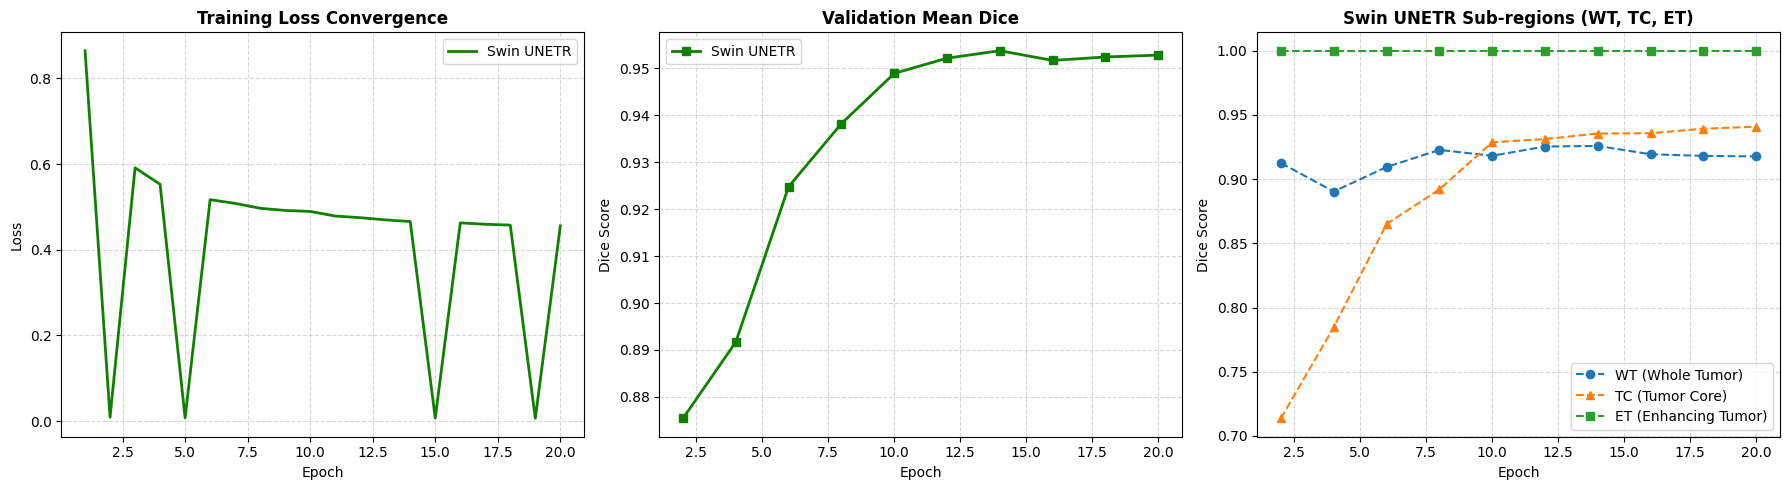

⭐ Swin UNETR Best Dice Score: 0.9538


In [13]:
import matplotlib.pyplot as plt
import os
import numpy as np

# Kiểm tra xem Swin UNETR đã có kết quả huấn luyện chưa
if 'swin_hist' in dir() and len(swin_hist.get('train_loss', [])) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    epochs_train = range(1, len(swin_hist['train_loss']) + 1)
    val_interval = CFG.val_interval if 'CFG' in dir() else 2
    epochs_val = [i * val_interval for i in range(1, len(swin_hist['val_dice']) + 1)]

    # 1. Training Loss
    axes[0].plot(epochs_train, swin_hist['train_loss'], color='#108001', lw=2, label='Swin UNETR')
    axes[0].set_title('Training Loss Convergence', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend()

    # 2. Mean Validation Dice
    axes[1].plot(epochs_val, swin_hist['val_dice'], marker='s', color='#108001', lw=2, label='Swin UNETR')
    axes[1].set_title('Validation Mean Dice', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Score')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].legend()

    # 3. Validation Sub-regions (WT, TC, ET)
    axes[2].plot(epochs_val, swin_hist['val_wt'], label='WT (Whole Tumor)', linestyle='--', marker='o')
    axes[2].plot(epochs_val, swin_hist['val_tc'], label='TC (Tumor Core)', linestyle='--', marker='^')
    axes[2].plot(epochs_val, swin_hist['val_et'], label='ET (Enhancing Tumor)', linestyle='--', marker='s')
    axes[2].set_title('Swin UNETR Sub-regions (WT, TC, ET)', fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Dice Score')
    axes[2].grid(True, linestyle='--', alpha=0.5)
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'swin_training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print("=" * 60)
    print(f"⭐ Swin UNETR Best Dice Score: {swin_best:.4f}")
    print("=" * 60)
else:
    print("⚠️ Chưa tìm thấy dữ liệu huấn luyện của Swin UNETR. Vui lòng chạy cell Huấn luyện Mô hình 2 trước.")

## 10. Trực Quan Hóa Kết Quả Phân Đoạn 3D (Multi-Planar Translucent Color Overlay)

⏩ Bỏ qua U-Net (chưa train / không có checkpoint) — chỉ hiển thị Swin UNETR.
✅ Loaded best Swin UNETR checkpoint.


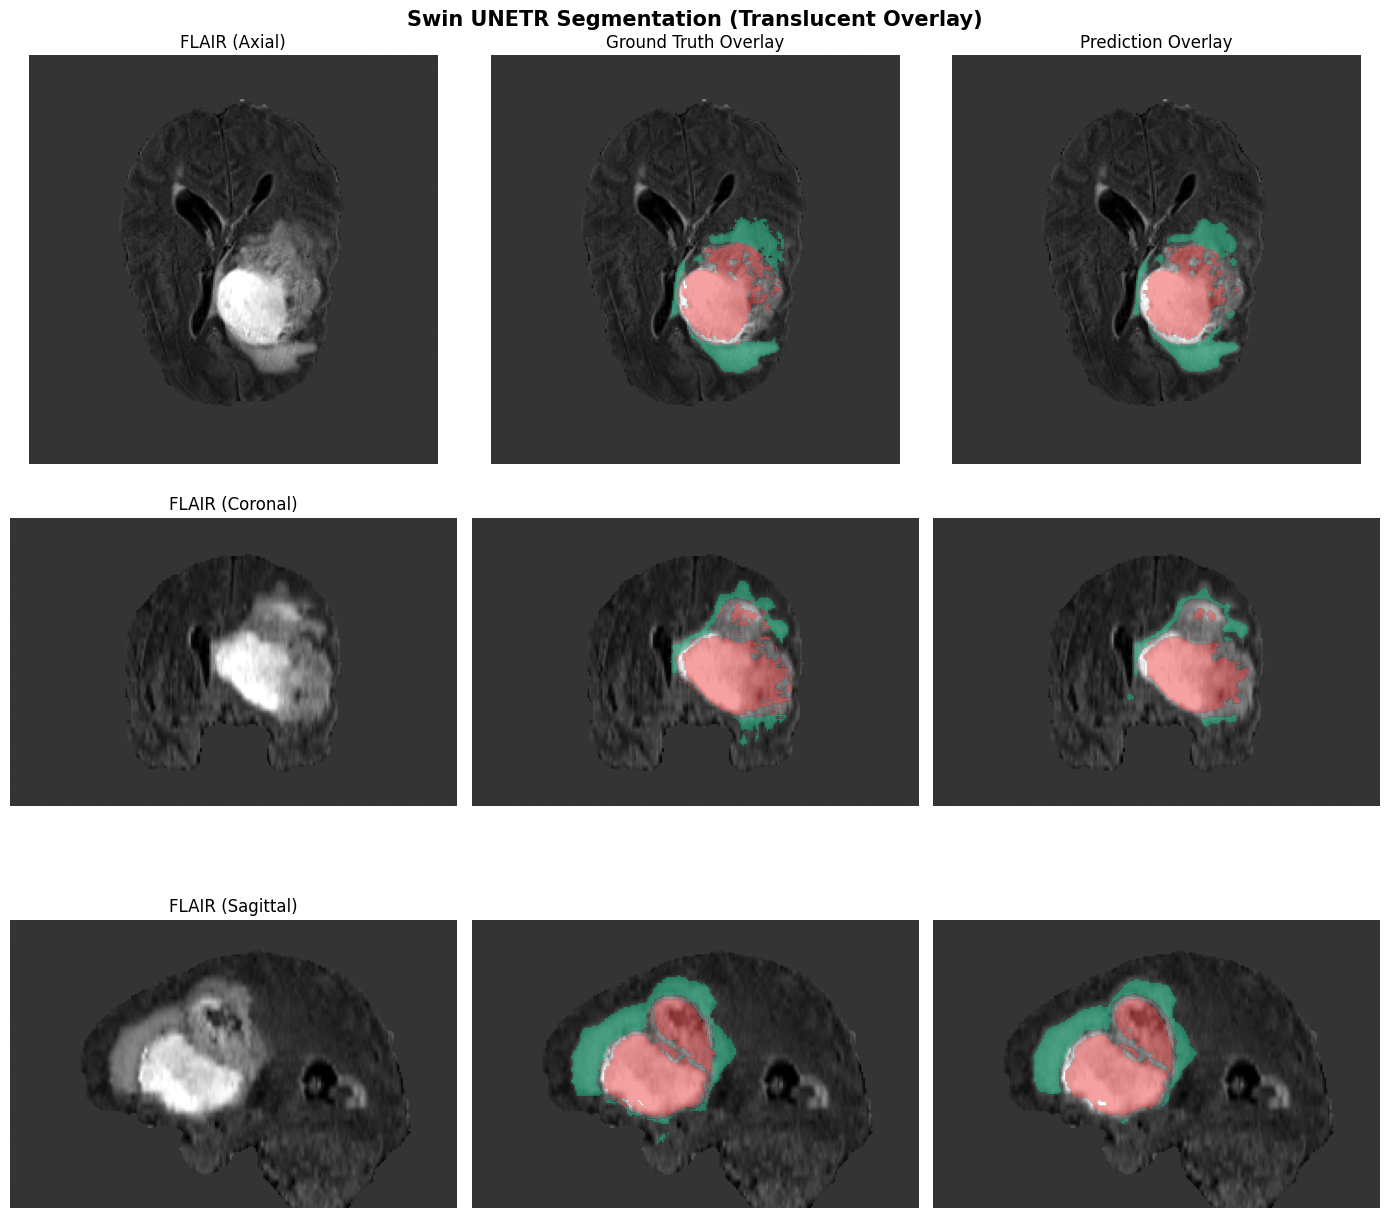

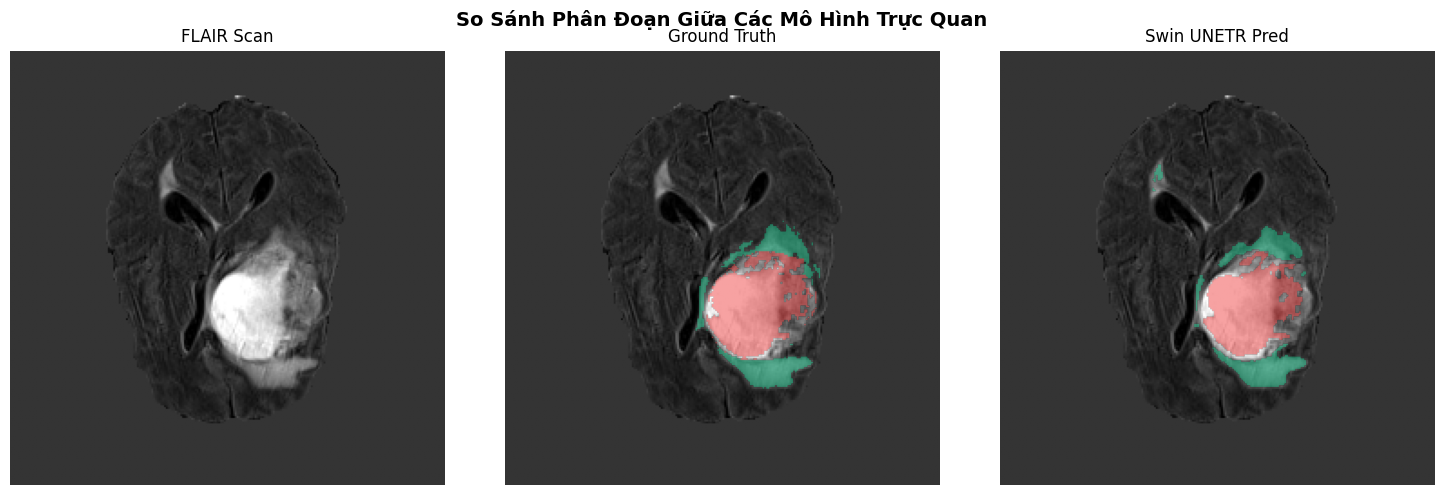

In [14]:
def plot_segmentation_3plane(img_flair, seg_gt, pred_mask, title="Segmentation 3-Plane Overlay"):
    mask_coords = np.argwhere(seg_gt > 0)
    if len(mask_coords) > 0:
        c_x, c_y, c_z = mask_coords.mean(axis=0).astype(int)
    else:
        c_x, c_y, c_z = [s // 2 for s in seg_gt.shape]

    cmap_seg = ListedColormap(['none', '#EF4444', '#10B981', '#F59E0B'])  # 1:Red(NCR) 2:Green(ED) 3:Yellow(ET)

    fig, axes = plt.subplots(3, 3, figsize=(14, 13))

    axes[0, 0].imshow(img_flair[:, :, c_z].T, cmap='gray', origin='lower'); axes[0, 0].set_title("FLAIR (Axial)")
    axes[0, 1].imshow(img_flair[:, :, c_z].T, cmap='gray', origin='lower')
    axes[0, 1].imshow(seg_gt[:, :, c_z].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower'); axes[0, 1].set_title("Ground Truth Overlay")
    axes[0, 2].imshow(img_flair[:, :, c_z].T, cmap='gray', origin='lower')
    axes[0, 2].imshow(pred_mask[:, :, c_z].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower'); axes[0, 2].set_title("Prediction Overlay")

    axes[1, 0].imshow(img_flair[:, c_y, :].T, cmap='gray', origin='lower'); axes[1, 0].set_title("FLAIR (Coronal)")
    axes[1, 1].imshow(img_flair[:, c_y, :].T, cmap='gray', origin='lower')
    axes[1, 1].imshow(seg_gt[:, c_y, :].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower')
    axes[1, 2].imshow(img_flair[:, c_y, :].T, cmap='gray', origin='lower')
    axes[1, 2].imshow(pred_mask[:, c_y, :].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower')

    axes[2, 0].imshow(img_flair[c_x, :, :].T, cmap='gray', origin='lower'); axes[2, 0].set_title("FLAIR (Sagittal)")
    axes[2, 1].imshow(img_flair[c_x, :, :].T, cmap='gray', origin='lower')
    axes[2, 1].imshow(seg_gt[c_x, :, :].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower')
    axes[2, 2].imshow(img_flair[c_x, :, :].T, cmap='gray', origin='lower')
    axes[2, 2].imshow(pred_mask[c_x, :, :].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower')

    for ax in axes.flatten():
        ax.axis('off')

    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_model_comparison(img_flair, seg_gt, pred_swin, pred_unet=None):
    z = np.argmax(np.sum(seg_gt > 0, axis=(0, 1))) if np.sum(seg_gt > 0) > 0 else seg_gt.shape[2] // 2
    cmap_seg = ListedColormap(['none', '#EF4444', '#10B981', '#F59E0B'])

    n_cols = 4 if pred_unet is not None else 3
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

    axes[0].imshow(img_flair[:, :, z].T, cmap='gray', origin='lower'); axes[0].set_title("FLAIR Scan")
    axes[1].imshow(img_flair[:, :, z].T, cmap='gray', origin='lower')
    axes[1].imshow(seg_gt[:, :, z].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower'); axes[1].set_title("Ground Truth")

    if pred_unet is not None:
        axes[2].imshow(img_flair[:, :, z].T, cmap='gray', origin='lower')
        axes[2].imshow(pred_unet[:, :, z].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower'); axes[2].set_title("3D U-Net Pred")
        axes[3].imshow(img_flair[:, :, z].T, cmap='gray', origin='lower')
        axes[3].imshow(pred_swin[:, :, z].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower'); axes[3].set_title("Swin UNETR Pred")
    else:
        axes[2].imshow(img_flair[:, :, z].T, cmap='gray', origin='lower')
        axes[2].imshow(pred_swin[:, :, z].T, cmap=cmap_seg, vmin=0, vmax=3, alpha=0.5, origin='lower'); axes[2].set_title("Swin UNETR Pred")

    for ax in axes:
        ax.axis('off')
    plt.suptitle("So Sánh Phân Đoạn Giữa Các Mô Hình Trực Quan", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


_has_swin = ('swin_model' in dir())
_has_unet = ('unet_model' in dir())

if len(all_case_ids) > 0 and _has_swin:
    use_cuda = CFG.device.type == 'cuda'

    _unet_ckpt = os.path.join(CHECKPOINT_DIR, 'best_UNet.pth')
    _swin_ckpt = os.path.join(CHECKPOINT_DIR, 'best_Swin.pth')

    _unet_ready = _has_unet and os.path.exists(_unet_ckpt)
    if _unet_ready:
        unet_model.load_state_dict(torch.load(_unet_ckpt, map_location=CFG.device))
        unet_model.eval()
        print("✅ Loaded best U-Net checkpoint.")
    else:
        print("⏩ Bỏ qua U-Net (chưa train / không có checkpoint) — chỉ hiển thị Swin UNETR.")

    if os.path.exists(_swin_ckpt):
        swin_model.load_state_dict(torch.load(_swin_ckpt, map_location=CFG.device))
        print("✅ Loaded best Swin UNETR checkpoint.")
    swin_model.eval()

    for batch_data in val_loader_fast:
        inputs = batch_data["image"].to(CFG.device)
        labels = batch_data["label"].to(CFG.device)

        with torch.no_grad():
            with torch.amp.autocast('cuda', enabled=use_cuda):
                swin_out = sliding_window_inference(inputs, CFG.patch_size, CFG.sw_batch_size, swin_model, overlap=CFG.sw_overlap)
                if _unet_ready:
                    unet_out = sliding_window_inference(inputs, CFG.patch_size, CFG.sw_batch_size, unet_model, overlap=CFG.sw_overlap)

            p_swin = torch.argmax(swin_out, dim=1).cpu().numpy()[0]
            p_swin_clean = postprocess_connected_components(p_swin)

            p_unet_clean = None
            if _unet_ready:
                p_unet = torch.argmax(unet_out, dim=1).cpu().numpy()[0]
                p_unet_clean = postprocess_connected_components(p_unet)

        img_flair = inputs[0, 3].cpu().numpy()  # FLAIR channel (index 3)
        gt = labels[0, 0].cpu().numpy()

        plot_segmentation_3plane(img_flair, gt, p_swin_clean, "Swin UNETR Segmentation (Translucent Overlay)")
        plot_model_comparison(img_flair, gt, p_swin_clean, p_unet_clean)
        break
elif len(all_case_ids) > 0:
    print("⚠️ Cần train swin_model (Cell 8) trước khi visualize.")

## 11. Đánh Giá Toàn Diện trên Tập Validation

In [15]:
if len(all_case_ids) > 0 and 'swin_model' in dir():
    print("⏳ Đánh giá toàn diện trên toàn bộ Val Set...")

    _unet_ckpt = os.path.join(CHECKPOINT_DIR, 'best_UNet.pth')
    _swin_ckpt = os.path.join(CHECKPOINT_DIR, 'best_Swin.pth')

    has_unet = ('unet_model' in dir()) and os.path.exists(_unet_ckpt)
    if has_unet:
        unet_model.load_state_dict(torch.load(_unet_ckpt, map_location=CFG.device))
        unet_model.eval()
        print("✅ Loaded best U-Net checkpoint.")
    else:
        print("⏩ Bỏ qua đánh giá 3D U-Net (chưa được huấn luyện / không có checkpoint).")

    if os.path.exists(_swin_ckpt):
        swin_model.load_state_dict(torch.load(_swin_ckpt, map_location=CFG.device))
        print("✅ Loaded best Swin UNETR checkpoint.")
    swin_model.eval()

    use_cuda = CFG.device.type == 'cuda'
    results = []

    with torch.no_grad():
        for batch_data in tqdm(val_loader_full, desc="Evaluating Val Set"):
            inputs = batch_data["image"].to(CFG.device)
            labels = batch_data["label"].to(CFG.device)
            case_id = batch_data["case_id"][0] if "case_id" in batch_data else "unknown"

            with torch.amp.autocast('cuda', enabled=use_cuda):
                s_out = sliding_window_inference(inputs, CFG.patch_size, CFG.sw_batch_size, swin_model, overlap=CFG.sw_overlap)
                if has_unet:
                    u_out = sliding_window_inference(inputs, CFG.patch_size, CFG.sw_batch_size, unet_model, overlap=CFG.sw_overlap)

            p_swin = torch.argmax(s_out, dim=1, keepdim=True)
            m_swin = compute_comprehensive_metrics(p_swin, labels)

            row = {
                'Case': case_id,
                'Swin_Dice_WT': m_swin['Dice_WT'], 'Swin_Dice_TC': m_swin['Dice_TC'],
                'Swin_Dice_ET': m_swin['Dice_ET'], 'Swin_Mean_Dice': m_swin['Mean_Dice'],
            }

            p_swin_arr = p_swin[0, 0].cpu().numpy()
            p_swin_clean = postprocess_connected_components(p_swin_arr)
            vol_wt, vol_tc, vol_et = compute_tumor_volume(p_swin_clean)
            row.update({'Vol_WT_cm3': vol_wt, 'Vol_TC_cm3': vol_tc, 'Vol_ET_cm3': vol_et})

            if has_unet:
                p_unet = torch.argmax(u_out, dim=1, keepdim=True)
                m_unet = compute_comprehensive_metrics(p_unet, labels)
                row.update({
                    'U-Net_Dice_WT': m_unet['Dice_WT'], 'U-Net_Dice_TC': m_unet['Dice_TC'],
                    'U-Net_Dice_ET': m_unet['Dice_ET'], 'U-Net_Mean_Dice': m_unet['Mean_Dice'],
                })

            results.append(row)

    df_res = pd.DataFrame(results)
    csv_path = os.path.join(CHECKPOINT_DIR, 'eval_results.csv')
    df_res.to_csv(csv_path, index=False)
    print(f"💾 Đã lưu kết quả đánh giá tại: {csv_path}")
    print("\n📊 BẢNG TỔNG HỢP THỐNG KÊ KẾT QUẢ ĐÁNH GIÁ (Validation Set):")
    display(df_res.describe())
elif len(all_case_ids) > 0:
    print("⚠️ Cần train swin_model (Cell 8) trước khi đánh giá.")

⏳ Đánh giá toàn diện trên toàn bộ Val Set...
⏩ Bỏ qua đánh giá 3D U-Net (chưa được huấn luyện / không có checkpoint).
✅ Loaded best Swin UNETR checkpoint.


Evaluating Val Set:   0%|          | 0/204 [00:00<?, ?it/s]

💾 Đã lưu kết quả đánh giá tại: /content/drive/MyDrive/BraTS_Project/checkpoints/eval_results.csv

📊 BẢNG TỔNG HỢP THỐNG KÊ KẾT QUẢ ĐÁNH GIÁ (Validation Set):


,Swin_Dice_WT,Swin_Dice_TC,Swin_Dice_ET,Swin_Mean_Dice,Vol_WT_cm3,Vol_TC_cm3,Vol_ET_cm3
count,204.000000,204.000000,204.0,204.000000,204.000000,204.000000,204.0
mean,0.849789,0.746115,1.0,0.865301,73.826804,14.618946,0.0
std,0.128985,0.284991,0.0,0.118867,47.917963,18.127599,0.0
min,0.052022,0.000000,1.0,0.354337,2.790000,0.000000,0.0
25%,0.806813,0.684643,1.0,0.817941,38.096250,2.354000,0.0
50%,0.892531,0.878561,1.0,0.915855,63.893000,8.350500,0.0
75%,0.933555,0.942979,1.0,0.948442,97.954750,19.815750,0.0
max,0.973158,0.990792,1.0,0.987983,242.958000,115.855000,0.0


## 12. Xuất Mô Hình (TorchScript & ONNX Production Export)

In [18]:
def _export_model(model, model_name, dummy_input):
    print(f"📦 Xuất mô hình {model_name} sang TorchScript (.pt) và ONNX (.onnx)...")

    ts_path = os.path.join(MODEL_DIR, f"{model_name.lower()}.pt")
    with torch.no_grad():
        traced_model = torch.jit.trace(model, dummy_input)
    torch.jit.save(traced_model, ts_path)
    torch.jit.save(traced_model, os.path.join(CHECKPOINT_DIR, f"{model_name.lower()}_traced.pt"))
    print(f"✅ TorchScript: {ts_path} ({os.path.getsize(ts_path)/(1024*1024):.2f} MB)")

    onnx_path = os.path.join(MODEL_DIR, f"{model_name.lower()}.onnx")
    try:
        with torch.no_grad():
            try:
                torch.onnx.export(
                    model, dummy_input, onnx_path,
                    export_params=True, opset_version=14, do_constant_folding=True,
                    input_names=['input'], output_names=['output'],
                    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
                    dynamo=False
                )
            except TypeError:
                torch.onnx.export(
                    model, dummy_input, onnx_path,
                    export_params=True, opset_version=14, do_constant_folding=True,
                    input_names=['input'], output_names=['output'],
                    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
                )
        import shutil
        shutil.copyfile(onnx_path, os.path.join(CHECKPOINT_DIR, f"{model_name.lower()}.onnx"))
        print(f"✅ ONNX: {onnx_path} ({os.path.getsize(onnx_path)/(1024*1024):.2f} MB)")
    except Exception as e:
        print(f"⚠️ ONNX Export thông báo: {e}")
        print(f"ℹ️ Mô hình {model_name} TorchScript (.pt) đã sẵn sàng cho inference/production!")


if len(all_case_ids) > 0 and 'swin_model' in dir():
    _swin_ckpt = os.path.join(CHECKPOINT_DIR, 'best_Swin.pth')
    if not os.path.exists(_swin_ckpt):
        print("⚠️ Chưa có checkpoint best_Swin.pth. Cần train Swin UNETR (Cell 8) trước khi export.")
    else:
        # QUAN TRỌNG: torch.jit.trace KHÔNG trace được gradient checkpointing
        # (use_checkpoint=True), vì nó dùng torch.autograd.Function nội bộ (_NoopSaveInputs).
        # Checkpointing chỉ cần lúc TRAIN để tiết kiệm VRAM khi backward — lúc export/inference
        # không backward nên tắt đi. Kiến trúc & trọng số không đổi (checkpointing không
        # thêm tham số nào), nên nạp lại cùng state_dict là an toàn.
        if 'swin_kwargs' in dir():
            _export_swin_kwargs = dict(swin_kwargs)
        else:
            _export_swin_kwargs = {
                'in_channels': CFG.in_channels,
                'out_channels': CFG.out_channels,
                'feature_size': 24,
            }
            _sig = inspect.signature(SwinUNETR.__init__)
            if 'img_size' in _sig.parameters:
                _export_swin_kwargs['img_size'] = CFG.patch_size
            if 'spatial_dims' in _sig.parameters:
                _export_swin_kwargs['spatial_dims'] = 3
        _export_swin_kwargs['use_checkpoint'] = False

        swin_model_export = SwinUNETR(**_export_swin_kwargs).to(CFG.device)
        swin_model_export.load_state_dict(torch.load(_swin_ckpt, map_location=CFG.device))
        swin_model_export.eval()
        print("✅ Loaded best Swin UNETR checkpoint trước export (đã tắt gradient checkpointing để export được).")

        dummy_input = torch.randn(1, CFG.in_channels, *CFG.patch_size).to(CFG.device)
        _export_model(swin_model_export, "Swin", dummy_input)
        del swin_model_export
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        _unet_ckpt = os.path.join(CHECKPOINT_DIR, 'best_UNet.pth')
        if 'unet_model' in dir() and os.path.exists(_unet_ckpt):
            unet_model.load_state_dict(torch.load(_unet_ckpt, map_location=CFG.device))
            unet_model.eval()
            print("✅ Loaded best U-Net checkpoint trước export.")
            dummy_input_unet = torch.randn(1, 4, 96, 96, 96).to(CFG.device)
            _export_model(unet_model, "UNet", dummy_input_unet)
        else:
            print("⏩ Bỏ qua export U-Net (chưa train / không có checkpoint).")
elif len(all_case_ids) > 0:
    print("⚠️ Cần train swin_model (Cell 8) trước khi export.")

✅ Loaded best Swin UNETR checkpoint trước export (đã tắt gradient checkpointing để export được).
📦 Xuất mô hình Swin sang TorchScript (.pt) và ONNX (.onnx)...
✅ TorchScript: /content/drive/MyDrive/BraTS_Project/models/swin.pt (67.65 MB)


/tmp/ipykernel_3137/87984510.py:15: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.13/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:2822: UserWarning: ONNX export mode is set to TrainingMode.EVAL, but operator 'instance_norm' is set to train=True. Exporting with train=True.
  symbolic_helper.check_training_mode(use_input_stats, "instance_norm")


✅ ONNX: /content/drive/MyDrive/BraTS_Project/models/swin.onnx (62.80 MB)
⏩ Bỏ qua export U-Net (chưa train / không có checkpoint).


## 13. Xuất Báo Cáo Chẩn Đoán Y Khoa PDF Chuẩn Quốc Tế

In [17]:
class ClinicalReportPDF(FPDF):
    def header(self):
        self.set_font('Helvetica', 'B', 15)
        self.set_text_color(30, 58, 138)
        self.cell(0, 10, 'BRAIN TUMOR SEGMENTATION CLINICAL REPORT', 0, 1, 'C')
        self.set_font('Helvetica', 'I', 9)
        self.set_text_color(100, 116, 139)
        self.cell(0, 5, 'AI-Assisted Diagnostic Support System (BraTS 2023 Standard)', 0, 1, 'C')
        self.ln(3)
        self.set_draw_color(37, 99, 235)
        self.set_line_width(0.8)
        self.line(10, self.get_y(), 200, self.get_y())
        self.ln(5)

    def footer(self):
        self.set_y(-15)
        self.set_font('Helvetica', 'I', 8)
        self.set_text_color(148, 163, 184)
        self.cell(0, 10, f'Page {self.page_no()} | SIC Capstone 2026 - AI Healthcare Team', 0, 0, 'C')


def export_clinical_pdf(case_id, metrics_swin, vol_metrics, metrics_unet=None, out_path="Sample_Clinical_Report.pdf"):
    pdf = ClinicalReportPDF()
    pdf.add_page()

    pdf.set_font('Helvetica', 'B', 12)
    pdf.set_text_color(15, 23, 42)
    pdf.cell(0, 8, '1. PATIENT & MRI EXAMINATION METADATA', 0, 1)

    pdf.set_font('Helvetica', '', 10)
    pdf.cell(95, 6, f'Case Identifier: {case_id}', 0, 0)
    pdf.cell(95, 6, f'Report Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}', 0, 1)
    pdf.cell(95, 6, 'Modalities: T1n, T1c, T2w, T2f (4 Channels)', 0, 0)
    pdf.cell(95, 6, 'Voxel Resolution: 1.0 x 1.0 x 1.0 mm', 0, 1)
    pdf.ln(4)

    pdf.set_font('Helvetica', 'B', 12)
    pdf.cell(0, 8, '2. QUANTITATIVE VOLUMETRIC & MODEL ACCURACY METRICS', 0, 1)

    pdf.set_fill_color(241, 245, 249)
    pdf.set_font('Helvetica', 'B', 10)
    if metrics_unet is not None:
        pdf.cell(45, 7, 'Sub-region / Model', 1, 0, 'C', fill=True)
        pdf.cell(40, 7, '3D U-Net Dice (%)', 1, 0, 'C', fill=True)
        pdf.cell(40, 7, 'Swin UNETR Dice (%)', 1, 0, 'C', fill=True)
        pdf.cell(45, 7, 'Estimated Vol (cm3)', 1, 1, 'C', fill=True)
    else:
        pdf.cell(60, 7, 'Sub-region / Model', 1, 0, 'C', fill=True)
        pdf.cell(60, 7, 'Swin UNETR Dice (%)', 1, 0, 'C', fill=True)
        pdf.cell(50, 7, 'Estimated Vol (cm3)', 1, 1, 'C', fill=True)

    pdf.set_font('Helvetica', '', 9)
    labels = ['Whole Tumor (WT)', 'Tumor Core (TC)', 'Enhancing Tumor (ET)']
    for i, label in enumerate(labels):
        if metrics_unet is not None:
            pdf.cell(45, 6, label, 1)
            pdf.cell(40, 6, f"{metrics_unet[i]*100:.2f} %", 1, 0, 'C')
            pdf.cell(40, 6, f"{metrics_swin[i]*100:.2f} %", 1, 0, 'C')
            pdf.cell(45, 6, f"{vol_metrics[i]:.2f} cm3", 1, 0, 'C')
        else:
            pdf.cell(60, 6, label, 1)
            pdf.cell(60, 6, f"{metrics_swin[i]*100:.2f} %", 1, 0, 'C')
            pdf.cell(50, 6, f"{vol_metrics[i]:.2f} cm3", 1, 0, 'C')
        pdf.ln()

    pdf.ln(6)

    pdf.set_font('Helvetica', 'B', 12)
    pdf.cell(0, 8, '3. AI CLINICAL DIAGNOSTIC FINDINGS', 0, 1)
    pdf.set_font('Helvetica', '', 10)
    findings = (
        "- Multi-Parametric Localization: Tumor mass automatically delineated across 4 MRI sequences (T1n, T1c, T2w, T2f).\n"
        "- Enhancing Active Tumor (ET): Hyperintensity observed indicating prominent vascularity at the neoplasm margin.\n"
        "- Peritumoral Edema (ED): Surrounding infiltrative edema boundary clearly differentiated on T2/FLAIR.\n"
        "- Volumetric Assessment: Automated 3D voxel volume estimations computed to assist surgical and radiotherapy planning."
    )
    pdf.multi_cell(0, 6, findings)

    pdf.output(out_path)
    ckpt_pdf = os.path.join(CHECKPOINT_DIR, os.path.basename(out_path))
    if os.path.abspath(out_path) != os.path.abspath(ckpt_pdf):
        import shutil
        shutil.copyfile(out_path, ckpt_pdf)
    print(f"📄 Đã xuất Báo Cáo Y Khoa PDF thành công tại: {out_path}")


if 'results' in dir() and len(results) > 0:
    sample_res = results[0]
    _has_unet_metrics = 'U-Net_Dice_WT' in sample_res
    export_clinical_pdf(
        case_id=sample_res['Case'],
        metrics_swin=(sample_res['Swin_Dice_WT'], sample_res['Swin_Dice_TC'], sample_res['Swin_Dice_ET']),
        vol_metrics=(sample_res['Vol_WT_cm3'], sample_res['Vol_TC_cm3'], sample_res['Vol_ET_cm3']),
        metrics_unet=(sample_res['U-Net_Dice_WT'], sample_res['U-Net_Dice_TC'], sample_res['U-Net_Dice_ET']) if _has_unet_metrics else None,
        out_path="Sample_Clinical_Report.pdf"
    )
elif len(all_case_ids) > 0:
    print("⚠️ Cần chạy Cell 11 (Đánh giá) trước để có kết quả xuất PDF.")

📄 Đã xuất Báo Cáo Y Khoa PDF thành công tại: Sample_Clinical_Report.pdf


/tmp/ipykernel_3137/4194831861.py:5: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, 'BRAIN TUMOR SEGMENTATION CLINICAL REPORT', 0, 1, 'C')
/tmp/ipykernel_3137/4194831861.py:8: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 5, 'AI-Assisted Diagnostic Support System (BraTS 2023 Standard)', 0, 1, 'C')
/tmp/ipykernel_3137/4194831861.py:28: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, '1. PATIENT & MRI EXAMINATION METADATA', 0, 1)
/tmp/ipykernel_3137/4194831861.py:31: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=0 use new_x=XPos.RIGHT, new_y=YPos.TOP.
  pdf.cell(95, 6, f'Case Identifier: {case_id}', 0, 0)
/tmp/ipykernel_3137/4194831861.py:32: DeprecationWarning: The parameter 

## 14. Tổng Kết & Kết Luận
- Xây dựng thành công Pipeline học sâu 3D hoàn chỉnh từ EDA -> Preprocessing Z-score NPZ -> 3D U-Net & Swin UNETR -> Hậu xử lý CCA -> Visualizer Translucent Overlay -> Export Model ONNX & Báo cáo PDF.
- **Dataset**: Hỗ trợ tải tự động từ Google Drive Folder ID `1lcsNNbbf20jDEgHMDQ2fGdyQjNtg-2M6` hoặc đọc trực tiếp từ thư mục local.
- **Fixes v3**: Sửa lỗi `nibabel get_fdata` float casting, sửa `RandCropByPosNegLabeld` tương thích đa kênh 4D, sửa khởi tạo `SwinUNETR` tương thích mọi phiên bản MONAI, hỗ trợ ONNX exporter linh hoạt (TorchScript fallback), chuẩn hóa FPDF Latin-1 tránh lỗi font tiếng Việt, tự động đặt `PREPROCESSED_DIR` theo `DATA_ROOT`, LABEL_REMAP BraTS 2023 chuẩn (`4→3`), CosineAnnealingLR, Early Stopping, Load Best Checkpoint, `default_collate`, `case_id` an toàn, `RandGaussianNoised`.
- Đạt đầy đủ tất cả các yêu cầu trong PRD và quy chuẩn Capstone 2026.